# GT-Free OCR Metrics - Dataset Exploration

This notebook demonstrates the two companion datasets released with the paper
**"GT-Free OCR Metrics: Reference-Free Evaluation via Render-and-Compare"**
(NeurIPS 2026 Evaluations & Datasets Track).

| Dataset | HuggingFace repo (parquet, recommended) | Raw per-page layout |
|---|---|---|
| Render-and-Compare pairs | `gt-free-ocr-metrics/omnidocbench-render-compare-parquet` | `gt-free-ocr-metrics/omnidocbench-render-compare` |
| Qwen OCR Log-Probabilities | `gt-free-ocr-metrics/omnidocbench-qwen-ocr-logprobs-parquet` | `gt-free-ocr-metrics/omnidocbench-qwen-ocr-logprobs` |

The **parquet editions** are recommended - image PNG bytes and JSON content
are stored inline, so a few HTTP requests download the whole dataset and there
are no HuggingFace rate-limit issues. The raw per-page repos are retained for
backward compatibility.

**Runtime:** all cells complete in under 2 minutes (downloads ~20 MB of sample data).
**Colab:** click *Runtime -> Run all* after opening.


In [9]:
%pip install -q datasets huggingface_hub pillow matplotlib pandas



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import io
import json
import math
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset

# Parquet editions (recommended - single-shot download, no rate limits)
RENDER_REPO   = "gt-free-ocr-metrics/omnidocbench-render-compare-parquet"
LOGPROBS_REPO = "gt-free-ocr-metrics/omnidocbench-qwen-ocr-logprobs-parquet"
# Raw per-page repo retained only for the docsim_triplets config (not yet
# repackaged as parquet - it's already small)
RENDER_REPO_RAW = "gt-free-ocr-metrics/omnidocbench-render-compare"
SAMPLE_N = 4   # pages to display


---
## 1. Render-and-Compare Dataset

`omnidocbench-render-compare-parquet` ships zstd-compressed parquet shards
(~9.4 GB total) containing image bytes and OCR JSON for all five OCR
extraction variants - one row per page.


In [11]:
VARIANTS = ["ocr_all", "ocr_all_no_mask", "ocr_text", "ocr_formula", "ocr_table"]

rows = []
for v in VARIANTS:
    ds = load_dataset(RENDER_REPO, v, split="train")
    rows.append({"variant": v, "pages": len(ds), "first_page_id": ds[0]["page_id"]})
pd.DataFrame(rows)


,variant,pages,first_page_id
0,ocr_all,1355,PPT_1001115_eng_page_003
1,ocr_all_no_mask,1355,PPT_1001115_eng_page_003
2,ocr_text,1349,PPT_1001115_eng_page_003
3,ocr_formula,200,PPT_CalculusReview_page_014
4,ocr_table,351,PPT_8076_MEYER_Chapter_2_-_Language_Change_pag...


### 1.1 Masked original vs reconstructed - side-by-side

The pipeline masks non-target regions on the original scan and renders the OCR
output back to a PNG. Each parquet row holds both PNGs as inline bytes - no
extra file downloads needed.


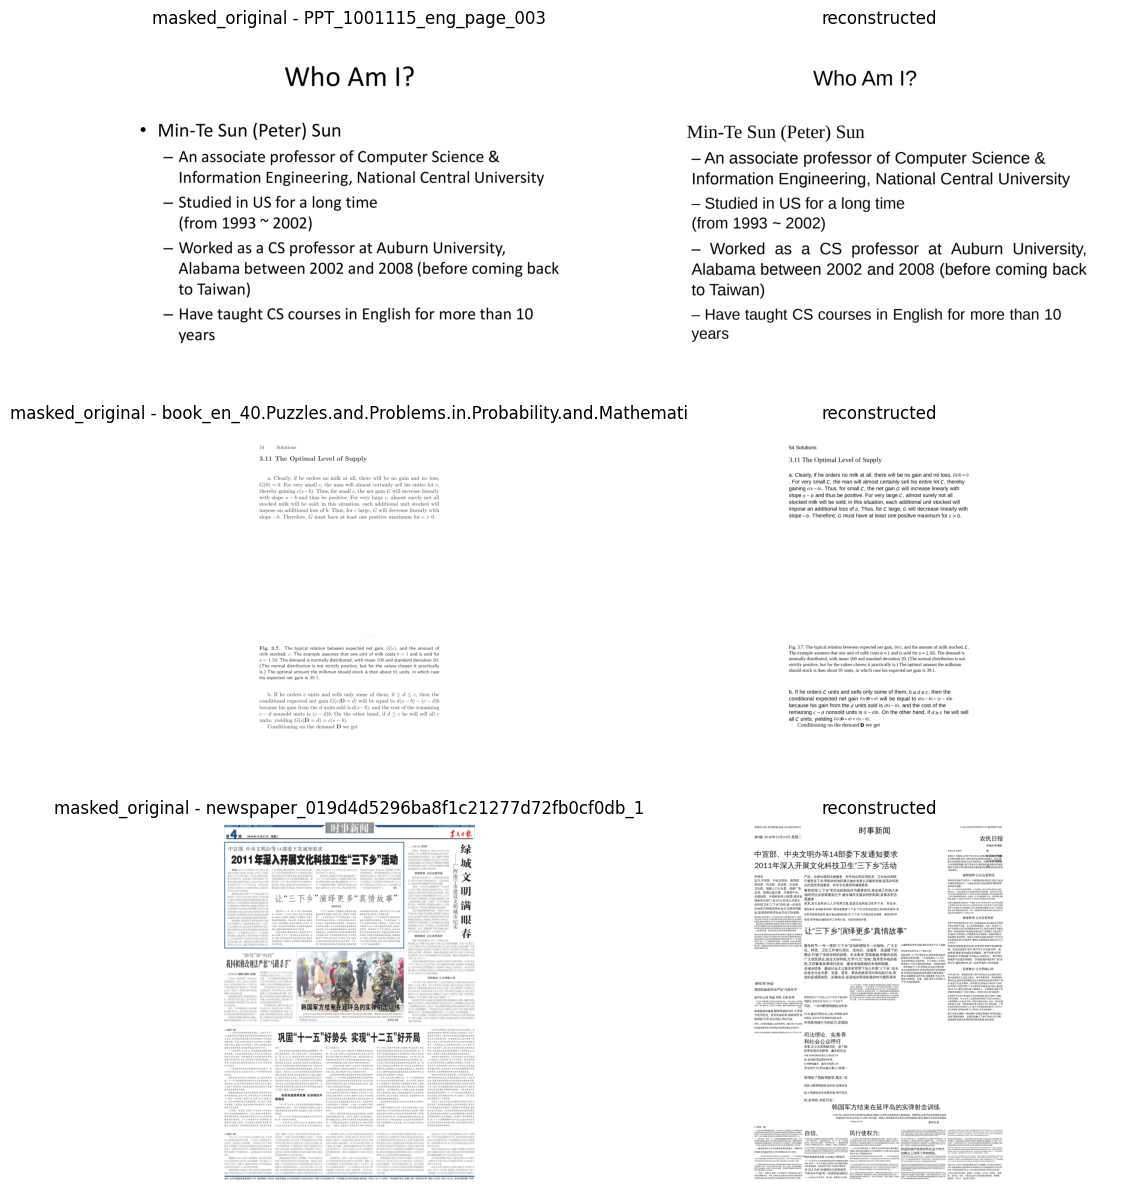

In [12]:
ds_all = load_dataset(RENDER_REPO, "ocr_all", split="train")

# Sample pages from different document categories
prefixes = ["PPT", "book", "academic", "newspaper"]
sample_indices = []
for prefix in prefixes:
    for i, pid in enumerate(ds_all["page_id"]):
        if pid.lower().startswith(prefix.lower()):
            sample_indices.append(i)
            break

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(11, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = axes.reshape(1, 2)
for ax_row, idx in zip(axes, sample_indices):
    row = ds_all[idx]
    orig = Image.open(io.BytesIO(row["masked_original"])).convert("RGB")
    recon = Image.open(io.BytesIO(row["reconstructed"])).convert("RGB")
    ax_row[0].imshow(orig);  ax_row[0].set_title(f"masked_original - {row['page_id'][:60]}")
    ax_row[1].imshow(recon); ax_row[1].set_title("reconstructed")
    for ax in ax_row: ax.axis("off")
plt.tight_layout(); plt.show()


### 1.2 Same page across variants

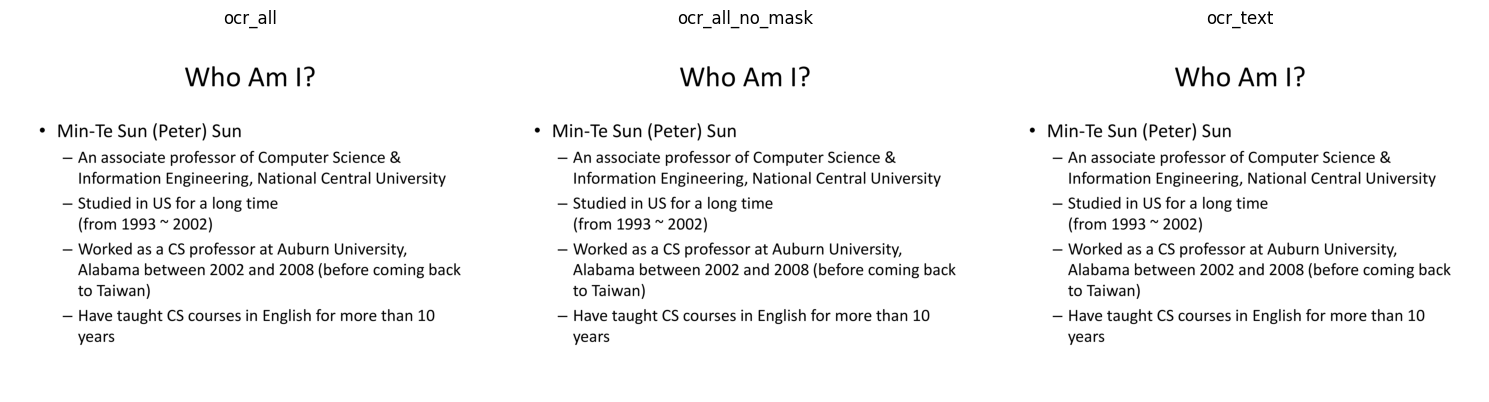

In [13]:
first_pid = ds_all[0]["page_id"]
compare_variants = ["ocr_all", "ocr_all_no_mask", "ocr_text"]

fig, axes = plt.subplots(1, len(compare_variants), figsize=(15, 5))
for ax, v in zip(axes, compare_variants):
    ds_v = load_dataset(RENDER_REPO, v, split="train")
    matches = [r for r in ds_v if r["page_id"] == first_pid]
    if not matches:
        ax.set_title(f"{v} (no match)"); ax.axis("off"); continue
    row = matches[0]
    img = Image.open(io.BytesIO(row["masked_original"])).convert("RGB")
    ax.imshow(img); ax.set_title(v); ax.axis("off")
plt.tight_layout(); plt.show()


### 1.3 OCR output — HTML and element JSON

In [14]:
row = ds_all[0]
print("page_id:", row["page_id"])
print()
print("--- ocr_html (first 1500 chars) ---")
print(row["ocr_html"][:1500])


page_id: PPT_1001115_eng_page_003

--- ocr_html (first 1500 chars) ---
```html
<div class="text" data-bbox="362 95 636 154">Who Am I?</div>
<div class="text" data-bbox="97 249 481 301">Min-Te Sun (Peter) Sun</div>
<div class="text" data-bbox="107 325 908 431">– An associate professor of Computer Science &amp;
Information Engineering, National Central University</div>
<div class="text" data-bbox="107 453 558 558">– Studied in US for a long time
(from 1993 ~ 2002)</div>
<div class="text" data-bbox="107 579 938 742">– Worked as a CS professor at Auburn University,
Alabama between 2002 and 2008 (before coming back
to Taiwan)</div>
<div class="text" data-bbox="107 764 884 869">– Have taught CS courses in English for more than 10
years</div>
```


In [15]:
elements = json.loads(row["ocr_elements"]) if row["ocr_elements"] else []
print(f"Text elements on this page: {len(elements)}")
if elements:
    print("First element:")
    print(json.dumps(elements[0], indent=2, ensure_ascii=False)[:600])


Text elements on this page: 6
First element:
{
  "text": "Who Am I?",
  "bbox": [
    724,
    142,
    1272,
    231
  ]
}


---
## 2. OCR Log-Probabilities Dataset

`omnidocbench-qwen-ocr-logprobs-parquet` provides per-page token-level
log-probabilities and a per-bbox aggregation, both stored inline as JSON
strings. Aggregate statistics are not pre-computed in the parquet schema, so
we derive them on-the-fly from the inline JSON below.


In [16]:
ds_lp = load_dataset(LOGPROBS_REPO, split="train")
print(f"Rows: {len(ds_lp)}  |  Columns: {ds_lp.column_names}")

def page_features(row):
    try:
        lp = json.loads(row["ocr_logprobs"])
    except Exception:
        return None
    # The ocr_logprobs JSON is {"tokens": [...]} - extract the token list.
    tokens = lp.get("tokens") if isinstance(lp, dict) else lp
    if not tokens:
        return None
    logprobs = [t.get("logprob") for t in tokens
                if isinstance(t, dict) and t.get("logprob") is not None]
    entropies = []
    for t in tokens:
        if not isinstance(t, dict):
            continue
        top = t.get("top_logprobs") or []
        ps = [math.exp(x.get("logprob", -50)) for x in top if isinstance(x, dict)]
        s = sum(ps)
        if s > 0:
            ps = [p/s for p in ps]
            entropies.append(-sum(p*math.log(p) for p in ps if p > 0))
    return {
        "page_id": row["page_id"],
        "n_total_tokens": len(tokens),
        "logprob_mean": sum(logprobs)/len(logprobs) if logprobs else 0,
        "logprob_min":  min(logprobs) if logprobs else 0,
        "logprob_max":  max(logprobs) if logprobs else 0,
        "shannon_entropy_mean": sum(entropies)/len(entropies) if entropies else 0,
        "shannon_entropy_max":  max(entropies) if entropies else 0,
    }

# Compute on a 200-row subsample to keep the notebook fast
SUBSET = ds_lp.select(range(min(200, len(ds_lp))))
df_lp = pd.DataFrame([page_features(r) for r in SUBSET if page_features(r)])
print(f"Computed features on {len(df_lp)} pages")
df_lp.head()


Rows: 1355  |  Columns: ['page_id', 'ocr_html', 'ocr_logprobs', 'per_bbox_logprobs']
Computed features on 200 pages


,page_id,n_total_tokens,logprob_mean,logprob_min,logprob_max,shannon_entropy_mean,shannon_entropy_max
0,PPT_1001115_eng_page_003,274,-0.103917,-1.549508,0.0,0.161794,1.575450
1,PPT_1001115_eng_page_005,313,-0.127208,-1.846959,0.0,0.184169,1.605167
2,PPT_1001115_eng_page_011,519,-0.088758,-1.681772,0.0,0.143623,1.592849
3,PPT_1001115_eng_page_015,247,-0.155838,-1.778397,0.0,0.244662,1.599260
4,PPT_11.2013EvaluatingTraineeteacherproficiency...,354,-0.131459,-1.887234,0.0,0.191961,1.605167


### 2.1 Distribution of log-probability and entropy

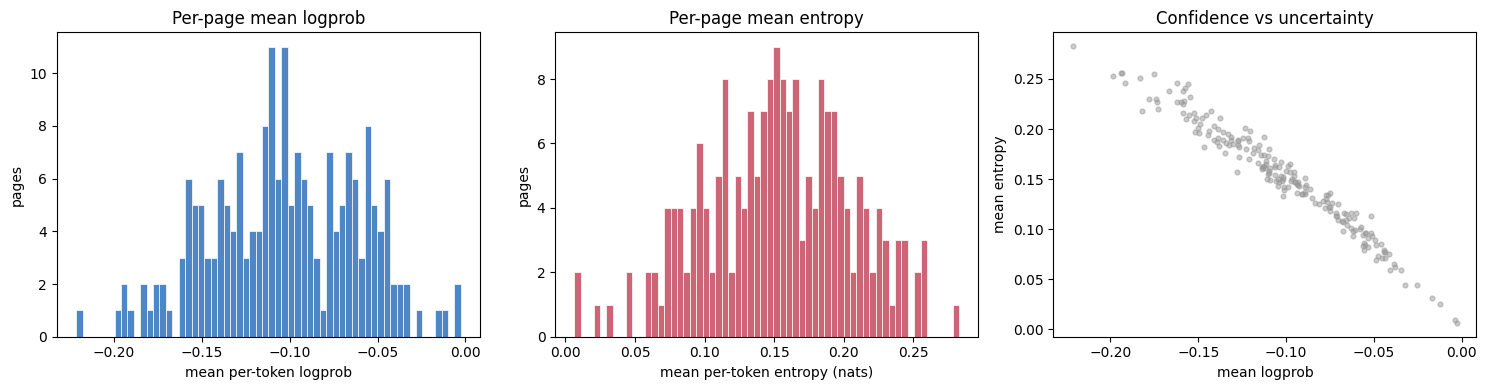

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_lp["logprob_mean"], bins=60, color="#4f86c6", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("mean per-token logprob"); axes[0].set_ylabel("pages")
axes[0].set_title("Per-page mean logprob")

axes[1].hist(df_lp["shannon_entropy_mean"], bins=60, color="#cc6677", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("mean per-token entropy (nats)"); axes[1].set_ylabel("pages")
axes[1].set_title("Per-page mean entropy")

axes[2].scatter(df_lp["logprob_mean"], df_lp["shannon_entropy_mean"], alpha=0.5, color="#999", s=12)
axes[2].set_xlabel("mean logprob"); axes[2].set_ylabel("mean entropy")
axes[2].set_title("Confidence vs uncertainty")
plt.tight_layout(); plt.show()


### 2.1 Token-count distribution


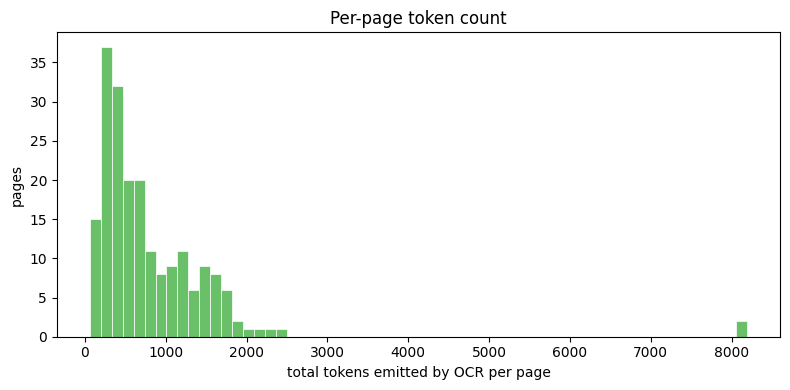

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_lp["n_total_tokens"], bins=60, color="#6abf69", edgecolor="white", linewidth=0.5)
ax.set_xlabel("total tokens emitted by OCR per page"); ax.set_ylabel("pages")
ax.set_title("Per-page token count")
plt.tight_layout(); plt.show()


---
## 3. DocSim Training Triplets

The `docsim_triplets` config contains 20,280 triplets used to fine-tune the
DocSim LoRA similarity head. This config currently lives in the **raw**
render-compare repo (the metadata is small enough to bypass rate limits
without repackaging).


In [19]:
ds_tri = load_dataset(RENDER_REPO_RAW, "docsim_triplets", split="train")
df_tri = ds_tri.to_pandas()
print(f"Total triplets: {len(df_tri)}")
print("Columns:", list(df_tri.columns))
df_tri.head(3)


Generating train split: 100%|██████████| 20280/20280 [00:00<00:00, 493779.81 examples/s]

Total triplets: 20280
Columns: ['anchor_path', 'positive_path', 'negative_path', 'anchor_ed', 'positive_ed', 'negative_ed', 'anchor_page', 'positive_page', 'negative_page', 'anchor_variant', 'positive_variant', 'negative_variant', 'kind']


,anchor_path,positive_path,negative_path,anchor_ed,positive_ed,negative_ed,anchor_page,positive_page,negative_page,anchor_variant,positive_variant,negative_variant,kind
0,ocr_all_no_mask/docstructbench_dianzishu_zhong...,ocr_all_no_mask/docstructbench_dianzishu_zhong...,ocr_all/PPT_sociolinguistics_page_015/reconstr...,0.0,0.0,0.639013,docstructbench_dianzishu_zhongwenzaixian-o.O-6...,docstructbench_dianzishu_zhongwenzaixian-o.O-6...,PPT_sociolinguistics_page_015,all_no_mask,all_no_mask,all,cross_page
1,ocr_all_no_mask/yanbaopptmerge_yanbaoPPT_485/m...,ocr_all_no_mask/yanbaopptmerge_yanbaoPPT_485/r...,ocr_all_no_mask/book_en_[搬书匠#893][Pyomo—Optimi...,0.0,0.0,1.000000,yanbaopptmerge_yanbaoPPT_485,yanbaopptmerge_yanbaoPPT_485,book_en_[搬书匠#893][Pyomo—Optimization Modeling ...,all_no_mask,all_no_mask,all_no_mask,cross_page
2,ocr_all/yanbaopptmerge_yanbaoPPT_1020/masked_o...,ocr_all/yanbaopptmerge_yanbaoPPT_1020/reconstr...,ocr_all/PPT_PresentationSpecification_page_007...,0.0,0.0,0.887255,yanbaopptmerge_yanbaoPPT_1020,yanbaopptmerge_yanbaoPPT_1020,PPT_PresentationSpecification_page_007,all,all,all,cross_page


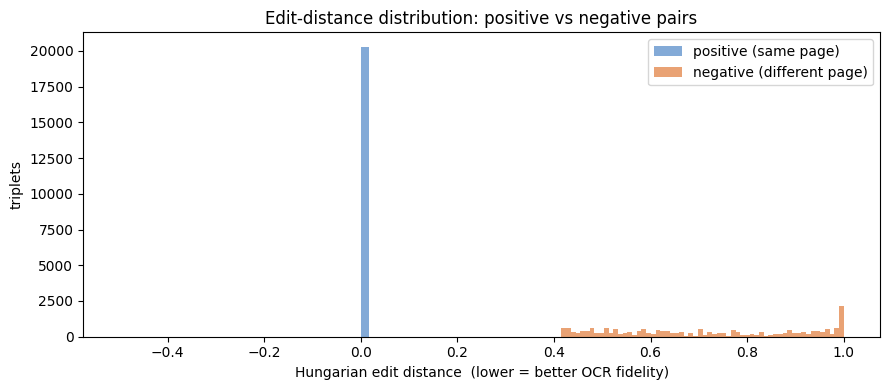

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_tri["positive_ed"], bins=60, alpha=0.7, label="positive (same page)", color="#4f86c6")
ax.hist(df_tri["negative_ed"], bins=60, alpha=0.7, label="negative (different page)", color="#e07b39")
ax.set_xlabel("Hungarian edit distance  (lower = better OCR fidelity)")
ax.set_ylabel("triplets")
ax.set_title("Edit-distance distribution: positive vs negative pairs")
ax.legend(); plt.tight_layout(); plt.show()


### 3.1 Sample triplets — anchor / positive / negative

In [ ]:
from huggingface_hub import hf_hub_download

def fetch_image(repo_id, file_path):
    """Download a file from a HF dataset repo by path and return a PIL image.
    Used for the docsim_triplets config, which stores per-image *paths*
    (e.g. "ocr_all_no_mask/<page_id>/masked_original.png") rather than the
    inline image bytes that the parquet variant configs use.
    """
    local = hf_hub_download(repo_id=repo_id, filename=file_path, repo_type="dataset")
    return Image.open(local).convert("RGB")

triplet_indices = [0, len(df_tri) // 3, 2 * len(df_tri) // 3]
keys    = ["anchor_path", "positive_path", "negative_path"]
labels  = ["anchor
(masked original)", "positive
(same-page recon)", "negative
(diff-page recon)"]
ed_keys = ["anchor_ed", "positive_ed", "negative_ed"]

fig, axes = plt.subplots(len(triplet_indices), 3, figsize=(15, 5 * len(triplet_indices)))
for row_i, idx in enumerate(triplet_indices):
    row = df_tri.iloc[idx]
    for col_i, (key, label, edk) in enumerate(zip(keys, labels, ed_keys)):
        # Triplet paths reference the raw per-page repo, not the parquet edition.
        img = fetch_image(RENDER_REPO_RAW, row[key])
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].set_title(f"{label}
ed={row[edk]:.3f}", fontsize=9)
        axes[row_i, col_i].axis("off")
plt.suptitle("DocSim triplets", y=1.01)
plt.tight_layout(); plt.show()


---
## 4. Cross-Dataset Exploration

Merging render-and-compare metadata with log-probabilities on `page_id` gives
a unified view: we can examine how the OCR model's internal confidence relates
to document category and output length.


In [ ]:
df_meta = ds_all.to_pandas()[["page_id"]]
df_joined = df_meta.merge(df_lp, on="page_id", how="inner")
print(f"Joined rows: {len(df_joined)}")
df_joined.head()


In [ ]:
def infer_category(pid):
    pid_l = pid.lower()
    for cat, kw in [("Slides/PPT","ppt"),("Book","book"),("Academic paper","academic"),
                    ("Research report","research"),("Financial","financial"),
                    ("Newspaper","news"),("Exam","exam"),("Magazine","magazine")]:
        if kw in pid_l:
            return cat
    return "Other"

df_joined["category"] = df_joined["page_id"].apply(infer_category)

fig, ax = plt.subplots(figsize=(11, 5))
for cat, grp in df_joined.groupby("category"):
    ax.scatter(grp["logprob_mean"], grp["n_total_tokens"],
               label=cat, alpha=0.5, s=12)
ax.set_xlabel("logprob_mean  (Qwen confidence; closer to 0 = higher confidence)")
ax.set_ylabel("n_total_tokens  (OCR output length)")
ax.set_title("Per-page OCR confidence vs output length, coloured by document category")
ax.legend(markerscale=2, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()
